<a href="https://colab.research.google.com/github/DeepFluxion/IBMEC_Aprendizado_Reforco_2026/blob/main/2026_aula_13_monte_carlo_unificado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🃏 Métodos Monte Carlo em Aprendizado por Reforço
## Aula 13 — Notebook Unificado

| # | Algoritmo | O que aprende | Exploração |
|---|---|---|---|
| 1 | **First-Visit MC Prediction** | $V(s)$ para política fixa | — |
| 2 | **MC Exploring-Starts (ES) Control** | $Q(s,a)$ + política ótima | Starts aleatórios |
| 3 | **On-Policy First-Visit MC Control** | $Q(s,a)$ + política ótima | ε-greedy |

---
> ⚠️ **Execute as células 1 e 2 antes de qualquer experimento** — elas carregam todos os imports e funções utilitárias.

In [ ]:
# Descomente se necessário:
!pip install gymnasium

## ⚙️ Célula 2 — Setup Completo

Esta célula centraliza **tudo que o notebook precisa** para funcionar: bibliotecas,
ambiente e funções utilitárias. Execute-a uma única vez antes de qualquer experimento.

---

### 📦 Importações e tipos auxiliares

Além das bibliotecas usuais (`numpy`, `pandas`, `matplotlib`), dois módulos merecem
atenção especial:

#### `from collections import defaultdict`

Um `defaultdict` é um dicionário que **nunca lança `KeyError`**: ao acessar uma chave
inexistente, ele cria automaticamente um valor padrão definido na sua construção.

```python
# Dicionário comum — lança KeyError se a chave não existe
d = {}
d['s1'].append(0.5)   # ❌ KeyError

# defaultdict(list) — cria uma lista vazia automaticamente
d = defaultdict(list)
d['s1'].append(0.5)   # ✅ funciona: d = {'s1': [0.5]}
```

Nos algoritmos Monte Carlo isso é essencial: precisamos acumular retornos
$G_t$ em `Returns[s]` para **todos os estados visitados**, sem saber de antemão
quais estados o agente irá visitar. O `defaultdict(list)` elimina a necessidade
de verificar `if s not in Returns` antes de cada `append`.

| Construtor | Valor padrão criado | Uso neste notebook |
|---|---|---|
| `defaultdict(list)` | `[]` | Acumular retornos `Returns[s]` |
| `defaultdict(float)` | `0.0` | Inicializar `Q(s,a)` e somas |
| `defaultdict(int)` | `0` | Contadores de visitas `N(s,a)` |

---

#### `from typing import Callable, Dict, List, Tuple, Any`

O módulo `typing` permite **anotar os tipos** das variáveis e parâmetros de funções.
As anotações não alteram o comportamento do código — servem como documentação
legível por humanos *e* por ferramentas como linters e IDEs.

| Tipo | O que representa | Exemplo neste notebook |
|---|---|---|
| `Tuple[int, int, bool]` | Tupla com 3 elementos de tipos fixos | `State = (18, 6, True)` |
| `Callable[[State], Action]` | Função que recebe `State` e retorna `Action` | `policy_simples` |
| `Dict[Tuple, float]` | Dicionário de tupla → float | `Q[(s, a)] = 0.72` |
| `List` | Lista de qualquer elemento | `trajectory` |

O tipo `Policy = Callable[[State], Action]` é particularmente útil: ele expressa
diretamente a definição matemática de política — $\pi : \mathcal{S} \rightarrow \mathcal{A}$
— e permite passar qualquer função (simples, avançada, ε-greedy) onde uma política
é esperada, sem mudar a assinatura das funções dos algoritmos.

---

### 🌍 Ambiente: Blackjack

O bloco `try/except` garante compatibilidade com duas versões da biblioteca:

```python
try:
    import gymnasium as gym          # versão mais recente (recomendada)
    env = gym.make('Blackjack-v1')
except Exception:
    import gym                       # fallback para versão antiga
    env = gym.make('Blackjack-v0')
```

A diferença entre elas é apenas na API de retorno do `env.step()` e `env.reset()`,
tratada pelos helpers `_reset_env` e `_step_env` descritos a seguir.

---

### 🔧 Helpers de API (`_reset_env` e `_step_env`)

O Gymnasium moderno retorna uma **tupla** em `reset()` — `(state, info)` — enquanto
o Gym antigo retorna apenas `state`. Os helpers absorvem essa diferença:

```python
def _reset_env(env) -> State:
    result = env.reset()
    return result[0] if isinstance(result, tuple) else result
    #      ↑ Gymnasium                              ↑ Gym antigo
```

Da mesma forma, `env.step()` retorna 4 valores no Gymnasium
(`state, reward, terminated, truncated`) e 3 no Gym antigo. O `_step_env`
combina `terminated or truncated` em um único booleano `done`, que é a
convenção usada em todo o notebook.

---

### 🎬 `generate_episode` — O coração de todos os algoritmos MC

Todos os três algoritmos Monte Carlo dependem de **episódios completos**.
Esta função os gera de forma genérica, aceitando qualquer política:

```python
while not done:
    action               = policy(state)          # π(s)
    next_state, reward, done = _step_env(env, action)
    trajectory.append((state, reward, done, action))
    state = next_state
```

Cada elemento de `trajectory` é uma tupla `(Sₜ, Rₜ₊₁, done, Aₜ)`,
reproduzindo exatamente a notação do Sutton: $S_0, A_0, R_1, S_1, A_1, R_2, \ldots, S_T$.
O índice `T` retornado é o comprimento da trajetória menos 1 — necessário
para o loop `reversed(range(T+1))` que percorre o episódio de trás para frente.

---

### 📊 Funções de visualização

| Função | Entrada | O que plota |
|---|---|---|
| `plot_value_heatmap(V)` | `dict {state: float}` | Valor $V(s)$ em escala verde→vermelho para os 200 estados do Blackjack, separados por ás usável |
| `plot_policy_heatmap(pi)` | `dict {state: int}` | Decisão da política: verde = STICK, vermelho = HIT |

Ambas dividem os estados em dois painéis: **com ás usável** (ás contando como 11)
e **sem ás usável**, pois o valor e a política ótima diferem significativamente
entre esses dois grupos.

> 💡 **Nota técnica:** `matplotlib.colormaps['RdYlGn'].resampled(2)` é a forma
> moderna de obter um colormap discreto de 2 cores. O bloco `try/except` garante
> compatibilidade com versões anteriores do matplotlib que usavam `plt.cm.get_cmap`.

---

### 🏆 `avaliar_politica` — Estimativa empírica do desempenho

Simula `n_jogos` partidas completas e conta vitórias, empates e derrotas.
É usada para **comparar quantitativamente** as políticas aprendidas pelos
diferentes algoritmos ao final do notebook.

In [ ]:
# ==============================================================
# CÉLULA 2 — SETUP COMPLETO
# Imports + Ambiente + Todos os utilitários compartilhados
# ==============================================================

from __future__ import annotations
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from collections import defaultdict
from typing import Callable, Dict, List, Tuple, Any

# --- Ambiente ---
try:
    import gymnasium as gym
    env = gym.make('Blackjack-v1')
    print('✓ Usando Gymnasium (Blackjack-v1)')
except Exception:
    import gym
    env = gym.make('Blackjack-v0')
    print('✓ Usando Gym (Blackjack-v0)')

# --- Tipos ---
State  = Tuple[int, int, bool]   # (soma_jogador, carta_dealer, as_usavel)
Action = int                      # 0=STICK | 1=HIT
Policy = Callable[[State], Action]
QDict  = Dict[Tuple, float]


# --------------------------------------------------------------
# Helpers de API (compatíveis com Gym e Gymnasium)
# --------------------------------------------------------------
def _reset_env(env) -> State:
    result = env.reset()
    return result[0] if isinstance(result, tuple) else result

def _step_env(env, action: int) -> Tuple[State, float, bool]:
    result     = env.step(action)
    state      = result[0]
    reward     = result[1]
    terminated = result[2]
    truncated  = result[3] if len(result) > 3 else False
    return state, reward, terminated or truncated


# --------------------------------------------------------------
# Utilitário 1 — Geração de episódio
# --------------------------------------------------------------
def generate_episode(env, policy: Policy) -> Tuple[List, int]:
    """
    Executa um episódio completo seguindo `policy`.
    Retorna:
        trajectory : lista de (state, reward, done, action)
        T          : índice do último passo
    """
    trajectory = []
    state      = _reset_env(env)
    done       = False

    while not done:
        action               = policy(state)
        next_state, reward, done = _step_env(env, action)
        trajectory.append((state, reward, done, action))
        state = next_state

    return trajectory, len(trajectory) - 1


# --------------------------------------------------------------
# Utilitário 2 — Heatmap de V(s)
# --------------------------------------------------------------
def _state_dict_to_array(d: dict, has_ace: bool) -> np.ndarray:
    arr = np.zeros((10, 10))
    for ps in range(12, 22):
        for dc in range(1, 11):
            arr[ps - 12, dc - 1] = d.get((ps, dc, has_ace), 0.0)
    return arr

def plot_value_heatmap(V: dict, title: str = 'V(s)', fmt: str = '.2f'):
    """Plota heatmap de V(s) para estados com e sem as usavel."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, ace, label in zip(axes, [True, False],
                               ['Com As Usavel', 'Sem As Usavel']):
        arr = _state_dict_to_array(V, ace)
        im  = ax.imshow(arr, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
        ax.set_title(f'{title} — {label}', fontsize=11)
        ax.set_xlabel('Carta Visivel do Dealer (1=As, 2-10)')
        ax.set_ylabel('Soma do Jogador (12-21)')
        ax.set_xticks(range(10)); ax.set_xticklabels(range(1, 11))
        ax.set_yticks(range(10)); ax.set_yticklabels(range(12, 22))
        plt.colorbar(im, ax=ax)
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


# --------------------------------------------------------------
# Utilitário 3 — Heatmap de Política
# --------------------------------------------------------------
def plot_policy_heatmap(policy_dict: dict, title: str = 'Politica'):
    """Plota mapa da politica greedy (verde=STICK, vermelho=HIT)."""
    # get_cmap foi depreciado no matplotlib 3.7+
    try:
        cmap = matplotlib.colormaps['RdYlGn'].resampled(2)
    except (AttributeError, KeyError):
        cmap = plt.cm.get_cmap('RdYlGn', 2)   # fallback versoes antigas

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, ace, label in zip(axes, [True, False],
                               ['Com As Usavel', 'Sem As Usavel']):
        arr = np.full((10, 10), np.nan)
        for ps in range(12, 22):
            for dc in range(1, 11):
                s = (ps, dc, ace)
                if s in policy_dict:
                    arr[ps - 12, dc - 1] = float(policy_dict[s])
        im = ax.imshow(arr, cmap=cmap, vmin=0, vmax=1, aspect='auto')
        ax.set_title(f'{title} — {label}', fontsize=11)
        ax.set_xlabel('Carta Visivel do Dealer')
        ax.set_ylabel('Soma do Jogador')
        ax.set_xticks(range(10)); ax.set_xticklabels(range(1, 11))
        ax.set_yticks(range(10)); ax.set_yticklabels(range(12, 22))
        cbar = plt.colorbar(im, ax=ax, ticks=[0.25, 0.75])
        cbar.set_ticklabels(['STICK (0)', 'HIT (1)'])
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


# --------------------------------------------------------------
# Utilitário 4 — Avaliação de política
# --------------------------------------------------------------
def avaliar_politica(env, policy: Policy, n_jogos: int = 10000) -> dict:
    """Calcula taxa de vitorias/empates/derrotas de uma politica."""
    vitorias = empates = derrotas = 0
    for _ in range(n_jogos):
        state  = _reset_env(env)
        done   = False
        reward = 0
        while not done:
            state, reward, done = _step_env(env, policy(state))
        if   reward > 0:  vitorias += 1
        elif reward == 0: empates  += 1
        else:             derrotas += 1
    stats = {'vitorias': vitorias/n_jogos,
             'empates':  empates /n_jogos,
             'derrotas': derrotas/n_jogos}
    for k, v in stats.items():
        print(f'  {k}: {v:.1%}')
    return stats


print('\n✓ Setup completo!')
print(f'  matplotlib {matplotlib.__version__} | numpy {np.__version__}')
print('  Funcoes disponiveis: generate_episode | plot_value_heatmap |',
      'plot_policy_heatmap | avaliar_politica')

✓ Usando Gymnasium (Blackjack-v1)

✓ Setup completo!
  matplotlib 3.10.0 | numpy 2.0.2
  Funcoes disponiveis: generate_episode | plot_value_heatmap | plot_policy_heatmap | avaliar_politica


---
## 🃏 1. O Ambiente: Blackjack

O estado é a tupla `(soma_jogador, carta_dealer, as_usavel)`:  
- `soma_jogador` ∈ [12, 21] | `carta_dealer` ∈ [1, 10] | `as_usavel` ∈ {True, False}  

**Ações:** `0` = STICK (parar) | `1` = HIT (pedir carta)  
**Recompensas:** `+1` vitória | `0` empate | `-1` derrota

---

A célula abaixo demonstra um episódio completo com **ações aleatórias**, percorrendo
o ciclo básico de interação com qualquer ambiente no padrão Gym/Gymnasium:

In [ ]:
state = _reset_env(env)
print(f'Estado inicial: soma={state[0]}, dealer={state[1]}, as_usavel={state[2]}')

done = False
step = 0
while not done:
    action = env.action_space.sample()
    next_state, reward, done = _step_env(env, action)
    step += 1
    print(f'  Passo {step}: {"HIT" if action else "STICK"} '
          f'-> estado={next_state}, recompensa={reward:+}, fim={done}')
    state = next_state

Estado inicial: soma=15, dealer=8, as_usavel=0
  Passo 1: HIT -> estado=(20, 8, 0), recompensa=+0.0, fim=False
  Passo 2: STICK -> estado=(20, 8, 0), recompensa=+1.0, fim=True


### `_reset_env(env)`

Recebe o objeto `env` criado na célula de setup e devolve **apenas o estado inicial**
$S_0$ como uma tupla `(soma_jogador, carta_dealer, as_usavel)`. Internamente, lida
com a diferença entre Gym (retorna só o estado) e Gymnasium (retorna `(estado, info)`),
de forma que o restante do código não precisa se preocupar com isso.

```python
state = _reset_env(env)
# Exemplo de retorno: (17, 6, False)
#   soma_jogador = 17
#   carta_dealer =  6  (carta visível do dealer)
#   as_usavel    = False
```

### `env.action_space.sample()`

Sorteia uma ação **uniformemente** no espaço de ações do ambiente — aqui `0` (STICK)
ou `1` (HIT) com probabilidade 50% cada. Esta é a forma canônica do Gym de
implementar uma política completamente aleatória, útil para demonstrações e testes.
Nos algoritmos MC reais ela será substituída por uma política aprendida ou ε-greedy.

### `_step_env(env, action)`

Recebe o `env` e a `action` escolhida, executa um passo no ambiente e retorna
três valores:

| Valor retornado | Tipo | Descrição |
|---|---|---|
| `next_state` | `Tuple[int, int, bool]` | Novo estado $S_{t+1}$ após a ação |
| `reward` | `float` | Recompensa $R_{t+1}$: `+1`, `0` ou `-1` |
| `done` | `bool` | `True` se o episódio terminou (vitória, derrota ou empate) |

> 💡 No Blackjack, `done` se torna `True` assim que o jogador para (STICK)
> ou estoura 21 — o episódio é sempre **curto**, tipicamente 1 a 5 passos.
> Essa característica torna o ambiente ideal para estudar métodos MC, que
> exigem episódios completos para calcular o retorno $G_t$.

---
## 🔵 Algoritmo 1 — First-Visit MC Prediction

**Objetivo:** estimar $V_\pi(s)$ para uma política **fixa** $\pi$.

$$G_t = R_{t+1} + \gamma G_{t+1}$$

```
Inicializar V(s), Returns(s) = []
Para cada episodio:
    Gerar S0,A0,R1, S1,A1,R2,...,ST  seguindo pi
    G <- 0
    Para t = T-1 ate 0:
        G <- gamma*G + R_{t+1}
        Se St nao aparece em S0,...,St-1:   <- primeira visita
            Returns(St).append(G)
            V(St) <- media(Returns(St))
```
> 📖 Sutton & Barto, Seção 5.1 (p. 92)

---

Antes de estimar $V_\pi(s)$, precisamos **fixar uma política** $\pi$ — o algoritmo
de Predição apenas avalia o quão boa ela é, sem modificá-la. A célula abaixo define
duas políticas determinísticas para o Blackjack, ambas com a assinatura
`policy(state: State) -> Action`, compatível com `generate_episode`.

### `policy_simples`

Implementa a heurística mais intuitiva do Blackjack: pedir carta enquanto a soma
for baixa e parar quando estiver alta.

```python
soma, _, _ = state   # ignora carta do dealer e ás usável (por isso _)
return 0 if soma >= 20 else 1
```

O limiar de 20 é deliberadamente conservador — o jogador só para quando está
muito perto de 21, o que na prática significa quase sempre pedir carta e arriscar
estourar. Essa política serve como **linha de base** (*baseline*): qualquer
algoritmo de controle que aprender uma política melhor deve superá-la.

### `policy_avancada`

Incorpora duas informações extras do estado que a política simples ignora:
a **carta visível do dealer** e se o jogador possui um **ás usável**.

```python
soma, dealer, ace = state   # desempacota os 3 campos do estado
```

A lógica de decisão segue uma sequência de regras em ordem de prioridade:

| Condição | Ação | Raciocínio |
|---|---|---|
| `soma >= 18` | STICK | Soma alta — risco de estouro supera o ganho |
| `ace and soma >= 17` | STICK | Ás usável protege contra estouro: se estourar, o ás vira 1 |
| `not ace and soma >= 17` | STICK | Sem ás, 17 já é um resultado razoável |
| `dealer >= 7 and soma < 17` | HIT | Dealer forte — precisamos melhorar a mão |
| `dealer <= 6 and soma >= 13` | STICK | Dealer fraco — deixamos ele estourar |
| (demais casos) | HIT | Por padrão, pedir carta |

> 💡 **Por que duas políticas?** O objetivo do Algoritmo 1 é mostrar que
> $V_\pi(s)$ **depende da política** — estados idênticos têm valores diferentes
> sob políticas diferentes. Comparar os heatmaps de $V_{\pi_\text{simples}}$ e
> $V_{\pi_\text{avançada}}$ torna isso visível de forma direta.
> Isso motiva naturalmente a próxima pergunta: *como encontrar a política que
> maximiza $V(s)$?* — que é o problema resolvido pelos Algoritmos 2 e 3.

In [ ]:
def policy_simples(state: State) -> Action:
    """STICK se soma >= 20, senao HIT."""
    soma, _, _ = state
    return 0 if soma >= 20 else 1

def policy_avancada(state: State) -> Action:
    """Considera as usavel e carta do dealer."""
    soma, dealer, ace = state
    if soma >= 18:                return 0
    if ace and soma >= 17:        return 0
    if not ace and soma >= 17:    return 0
    if dealer >= 7 and soma < 17: return 1
    if dealer <= 6 and soma >= 13: return 0
    return 1

print('Politicas definidas: policy_simples | policy_avancada')

Politicas definidas: policy_simples | policy_avancada


### Implementação — `first_visit_mc_prediction`

Esta função traduz o pseudocódigo do Sutton diretamente para Python.
Cada decisão de implementação tem uma correspondência exata com a teoria.

---

#### Parâmetros

| Parâmetro | Tipo | Padrão | Descrição |
|---|---|---|---|
| `env` | ambiente Gym | — | Ambiente Blackjack já instanciado |
| `policy` | `Callable[[State], Action]` | — | Política **fixa** $\pi$ a ser avaliada |
| `episodes` | `int` | `10000` | Número de episódios simulados |
| `gamma` | `float` | `1.0` | Fator de desconto $\gamma$ — no Blackjack usamos 1 pois a recompensa só ocorre no final |

---

#### Estruturas de dados internas

```python
Returns = defaultdict(list)   # Returns[s] = [G¹, G², G³, ...]
V       = {}                  # V[s] = média de Returns[s]
```

`Returns` acumula **todos os retornos observados** para cada estado ao longo
dos episódios. `V` guarda a estimativa atual de $V_\pi(s)$, atualizada a cada
nova visita. A separação entre os dois é importante: `Returns` é a memória
histórica, `V` é a estimativa que o algoritmo entrega ao final.

---

#### O loop externo — episódios

```python
for ep in range(1, episodes + 1):
    trajectory, T = generate_episode(env, policy)
```

A cada iteração, um episódio completo é simulado seguindo $\pi$. O resultado
é uma trajetória $S_0, A_0, R_1, S_1, A_1, R_2, \ldots, S_T$ armazenada como
lista de tuplas. É fundamental que o episódio seja **completo** — este é o
requisito central dos métodos Monte Carlo, que os diferencia do TD-Learning.

---

#### O loop interno — cálculo retroativo de $G_t$

```python
for t in reversed(range(T + 1)):
    state, reward, done, action = trajectory[t]
    G = gamma * G + reward
```

O loop percorre a trajetória **de trás para frente** ($t = T-1, T-2, \ldots, 0$).
Isso permite calcular $G_t$ de forma incremental, aproveitando a relação de
recorrência:

$$G_t = R_{t+1} + \gamma G_{t+1}$$

Se percorrêssemos do início para o fim, precisaríamos somar todos os
retornos futuros a cada passo — $O(T^2)$ operações. Percorrendo ao contrário,
cada $G_t$ custa apenas uma multiplicação e uma soma — $O(T)$ no total.

---

#### A condição de primeira visita

```python
if state not in visited:     # <- PRIMEIRA VISITA
    visited.add(state)
    Returns[state].append(G)
    V[state] = np.mean(Returns[state])
```

O conjunto `visited` é reiniciado a cada episódio e registra quais estados
já foram processados naquele episódio. A condição garante que, se $s$ aparecer
múltiplas vezes na trajetória, **apenas o $G_t$ da primeira ocorrência** é
usado para atualizar $V(s)$.

Isso é o que define o algoritmo como *First-Visit*. A variante *Every-Visit*
(Desafio 3) remove essa condição e atualiza $V(s)$ em toda ocorrência — ambas
convergem para $V_\pi(s)$, mas com propriedades estatísticas distintas.

> 💡 **Por que `np.mean` a cada visita e não só no final?**  
> Recomputar a média a cada episódio é simples de entender, mas ineficiente
> para muitos estados. Uma alternativa equivalente e mais eficiente é a
> **média incremental**, usada no Algoritmo 3:
> $$V(s) \leftarrow V(s) + \frac{1}{N(s)}\bigl[G - V(s)\bigr]$$
> Para fins didáticos, mantemos `np.mean` aqui para deixar a correspondência
> com o pseudocódigo mais direta.

---

#### Log de progresso

```python
if ep % 5000 == 0:
    print(f'  ep {ep:>6,}/{episodes:,} | estados estimados: {len(V)}')
```

A cada 5000 episódios, imprime quantos estados distintos já foram estimados.
Acompanhar `len(V)` é uma forma simples de observar a **cobertura** do espaço
de estados: no início os episódios exploram poucos estados; com mais episódios,
regiões menos visitadas da tabela de Blackjack começam a ser preenchidas.

In [ ]:
def first_visit_mc_prediction(
    env,
    policy:   Policy,
    episodes: int   = 10000,
    gamma:    float = 1.0
) -> dict:
    """
    First-Visit Monte Carlo Prediction.
    Estima V(s) para a politica fornecida.

    Retorna
    -------
    V : dict {state: valor_estimado}
    """
    Returns = defaultdict(list)
    V       = {}

    for ep in range(1, episodes + 1):
        trajectory, T = generate_episode(env, policy)
        G       = 0.0
        visited = set()

        for t in reversed(range(T + 1)):
            state, reward, done, action = trajectory[t]
            G = gamma * G + reward          # G_t = gamma*G_{t+1} + R_{t+1}

            if state not in visited:        # <- PRIMEIRA VISITA
                visited.add(state)
                Returns[state].append(G)
                V[state] = np.mean(Returns[state])

        if ep % 5000 == 0:
            print(f'  ep {ep:>6,}/{episodes:,} | estados estimados: {len(V)}')

    return V

### Execução — Política Simples

A célula abaixo roda o algoritmo e exibe os resultados. Alguns elementos merecem
atenção:

- **`%%time`** — magic command do Jupyter que mede o tempo total de execução da
célula. Útil para perceber o custo computacional de simular 20.000 episódios e
motivar otimizações como a média incremental usada no Algoritmo 3.

- **`episodes=20000`** — dobro do padrão (`10000`). Mais episódios reduzem a
variância da estimativa, especialmente para estados raramente visitados com a
`policy_simples` (por exemplo, estados com soma baixa, onde o agente quase
sempre pede carta e passa rapidamente por eles).

- **`plot_value_heatmap(V_simples, ...)`** — gera dois painéis lado a lado
(com e sem ás usável). Observe que estados com soma baixa tendem ao vermelho
($V(s) \approx -1$) e estados com soma alta tendem ao verde ($V(s) \approx 0$
ou positivo) — refletindo que a `policy_simples` só para quando está quase em
21, o que raramente acontece a partir de somas baixas.

- **`avaliar_politica(..., n_jogos=10000)`** — simulação independente do
treinamento: roda 10.000 partidas completas e reporta as taxas empíricas de
vitória, empate e derrota. Este número serve de **linha de base** para comparar
com as políticas aprendidas pelos Algoritmos 2 e 3 na seção de comparação final.

=== First-Visit MC Prediction — Politica Simples (>=20) ===
  ep  5,000/20,000 | estados estimados: 280
  ep 10,000/20,000 | estados estimados: 280
  ep 15,000/20,000 | estados estimados: 280
  ep 20,000/20,000 | estados estimados: 280

Estados estimados: 280


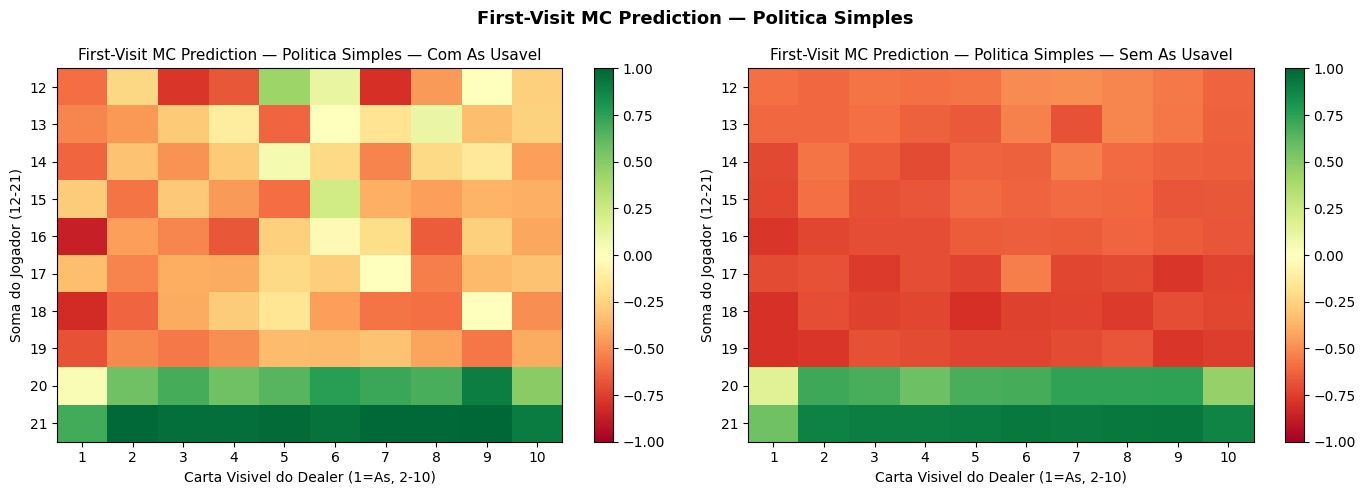


=== Avaliacao ===
  vitorias: 30.2%
  empates: 5.3%
  derrotas: 64.4%
CPU times: user 6.99 s, sys: 37.6 ms, total: 7.03 s
Wall time: 9.15 s


{'vitorias': 0.3024, 'empates': 0.0535, 'derrotas': 0.6441}

In [ ]:
%%time
print('=== First-Visit MC Prediction — Politica Simples (>=20) ===')
V_simples = first_visit_mc_prediction(env, policy_simples, episodes=20000)
print(f'\nEstados estimados: {len(V_simples)}')

plot_value_heatmap(V_simples, title='First-Visit MC Prediction — Politica Simples')

print('\n=== Avaliacao ===')
avaliar_politica(env, policy_simples, n_jogos=10000)

=== First-Visit MC Prediction — Politica Avancada ===
  ep  5,000/20,000 | estados estimados: 277
  ep 10,000/20,000 | estados estimados: 280
  ep 15,000/20,000 | estados estimados: 280
  ep 20,000/20,000 | estados estimados: 280

Estados estimados: 280


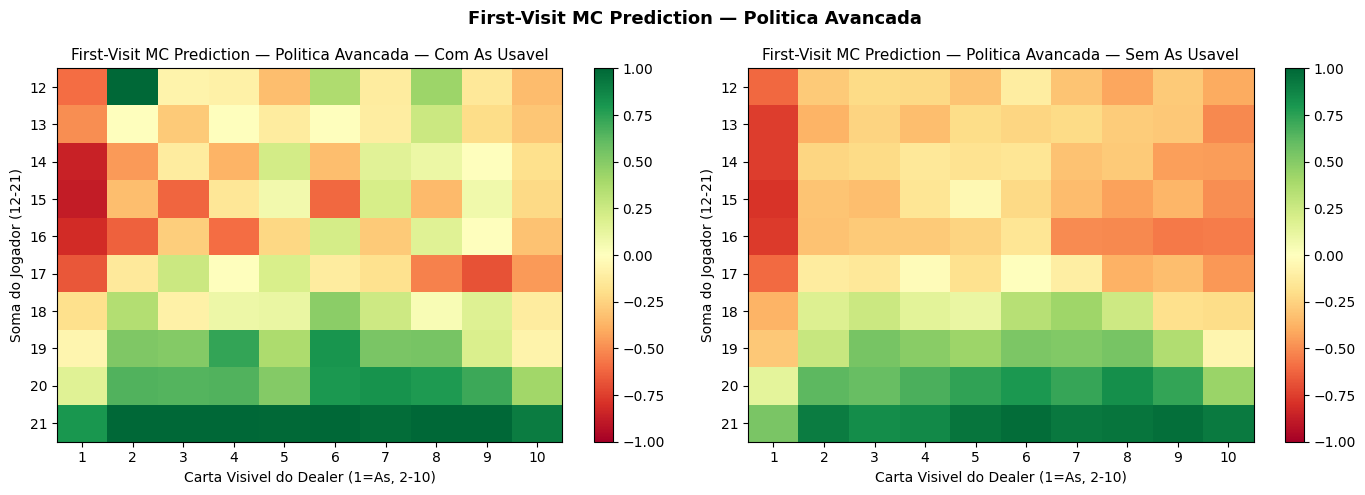


=== Avaliacao ===
  vitorias: 42.5%
  empates: 9.2%
  derrotas: 48.3%
CPU times: user 6.49 s, sys: 33.2 ms, total: 6.52 s
Wall time: 8.61 s


{'vitorias': 0.4249, 'empates': 0.0922, 'derrotas': 0.4829}

In [ ]:
%%time
print('=== First-Visit MC Prediction — Politica Avancada ===')
V_avancada = first_visit_mc_prediction(env, policy_avancada, episodes=20000)
print(f'\nEstados estimados: {len(V_avancada)}')
plot_value_heatmap(V_avancada, title='First-Visit MC Prediction — Politica Avancada')
print('\n=== Avaliacao ===')
avaliar_politica(env, policy_avancada, n_jogos=10000)

### Comparação entre as duas políticas de Predição

Até aqui rodamos o First-Visit MC Prediction duas vezes, cada uma com uma
política fixa diferente. Lembre-se: o algoritmo **não aprende nem melhora**
a política — ele apenas estima $V_\pi(s)$, o valor esperado de seguir $\pi$
a partir de cada estado. Portanto, políticas diferentes produzem funções de
valor diferentes.

O heatmap de diferença $V_{\pi_\text{avançada}}(s) - V_{\pi_\text{simples}}(s)$
torna essa comparação direta:

| Cor da célula | Significado |
|---|---|
| 🟢 Verde | A política avançada é mais vantajosa naquele estado |
| 🔴 Vermelha | A política simples é surpreendentemente melhor |
| 🟡 Amarela | As duas políticas têm desempenho equivalente |

#### O que esperar observar

- **Estados com soma baixa (12–16) e dealer fraco (2–6):** a política avançada
tende a ser melhor — ela para (STICK) nesses estados esperando que o dealer
estoure, enquanto a política simples continua pedindo carta desnecessariamente.

- **Estados com ás usável:** a política avançada reconhece que o ás funciona
como uma rede de segurança — é possível pedir carta com menos risco de estouro —
e isso se reflete em valores mais altos nesses estados.

- **Estados com soma alta (18–21):** as duas políticas convergem para STICK,
então a diferença tende a zero.

#### Por que isso importa para os próximos algoritmos?

Esta comparação ilustra um ponto fundamental: **a qualidade da política fixa
determina o teto do que a Predição consegue estimar**. O First-Visit MC
Prediction responde à pergunta *"quão boa é esta política?"*, mas não consegue
melhorá-la. Os Algoritmos 2 (MC ES Control) e 3 (On-Policy MC Control)
resolvem exatamente isso — eles aprendem $Q(s,a)$ em vez de $V(s)$, o que
permite derivar uma política melhor a cada episódio.

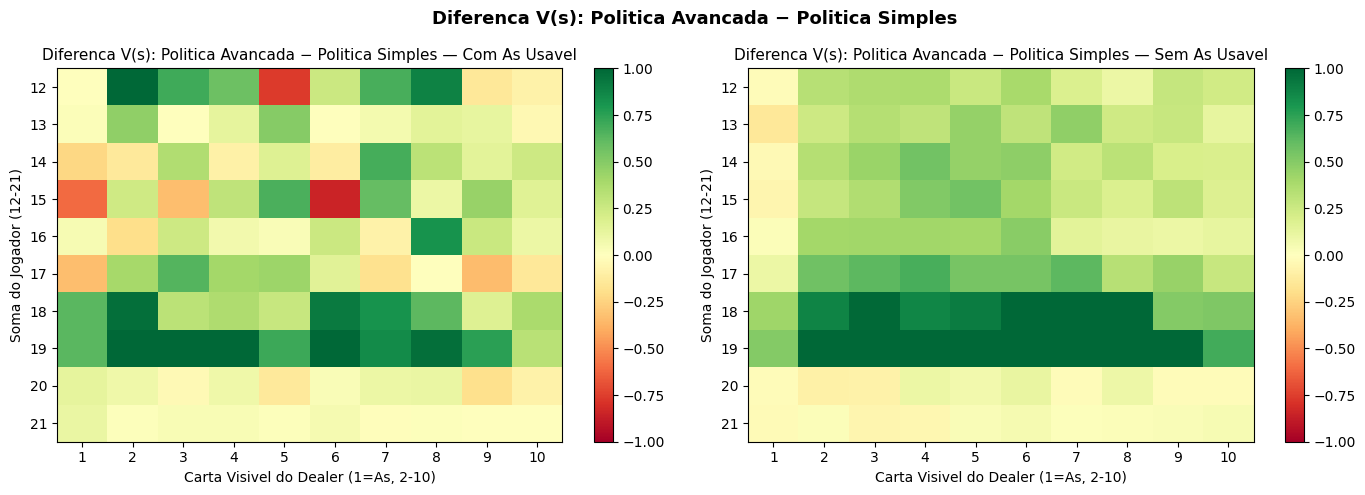

Estados onde avancada e melhor : 237
Estados onde simples e melhor  : 39
Estados empatados              : 4


In [ ]:
# --- Comparação direta: diferença V_avancada - V_simples ---
estados_comuns = set(V_avancada.keys()) & set(V_simples.keys())
V_diff = {s: V_avancada[s] - V_simples[s] for s in estados_comuns}

plot_value_heatmap(
    V_diff,
    title='Diferenca V(s): Politica Avancada − Politica Simples'
)
print(f'Estados onde avancada e melhor : {sum(1 for v in V_diff.values() if v > 0)}')
print(f'Estados onde simples e melhor  : {sum(1 for v in V_diff.values() if v < 0)}')
print(f'Estados empatados              : {sum(1 for v in V_diff.values() if v == 0)}')

---
## 🟡 Algoritmo 2 — Monte Carlo ES Control

**Objetivo:** aprender a política **ótima** usando *Exploring Starts*.

```
Inicializar Q(s,a), Returns(s,a) = [], pi arbitraria
Para cada episodio:
    Sortear (S0, A0) uniformemente
    Gerar episodio a partir de (S0, A0) seguindo pi
    G <- 0
    Para t = T-1 ate 0:
        G <- gamma*G + R_{t+1}
        Se (St,At) e primeira visita:
            Returns(St,At).append(G)
            Q(St,At) <- media(Returns)
            pi(St) <- argmax_a Q(St,a)   <- melhoria greedy
```
> 📖 Sutton & Barto, Seção 5.3 (p. 99)

## 🟡 Algoritmo 2 — Monte Carlo ES Control

**Objetivo:** aprender a política **ótima** usando *Exploring Starts*.

```
Inicializar Q(s,a), Returns(s,a) = [], pi arbitraria
Para cada episodio:
    Sortear (S0, A0) uniformemente
    Gerar episodio a partir de (S0, A0) seguindo pi
    G <- 0
    Para t = T-1 ate 0:
        G <- gamma*G + R_{t+1}
        Se (St,At) e primeira visita:
            Returns(St,At).append(G)
            Q(St,At) <- media(Returns)
            pi(St) <- argmax_a Q(St,a)   <- melhoria greedy
```
> 📖 Sutton & Barto, Seção 5.3 (p. 99)

---

### Por que precisamos de um novo ambiente?

No Algoritmo 1, o agente simplesmente seguia uma política fixa a partir do
estado que o ambiente sorteava. Aqui o problema é diferente: para garantir
que **todo par $(s, a)$ seja visitado**, o algoritmo precisa controlar o ponto
de partida de cada episódio — algo que o ambiente padrão do Blackjack não
permite. A classe `BlackjackES` resolve isso.

### `class BlackjackES` — Wrapper para Exploring Starts

#### Atributo de classe `STATES`

```python
STATES = [(ps, dc, ace)
          for ps  in range(4, 22)
          for dc  in range(1, 11)
          for ace in [True, False]]
```

Lista exaustiva de todos os estados válidos do Blackjack, construída por
compreensão de lista com três dimensões: soma do jogador (4–21), carta do
dealer (1–10) e presença de ás usável. São **360 estados** no total — o
espaço completo que os Exploring Starts precisam cobrir ao longo dos episódios.

#### Método `random_start`

```python
S0 = self.STATES[np.random.randint(len(self.STATES))]
A0 = np.random.choice(self.ACTIONS)
return S0, A0
```

Este é o **coração dos Exploring Starts**: a cada episódio, sorteia
uniformemente um estado $S_0$ da lista completa e uma ação $A_0 \in \{0, 1\}$.
Isso garante que, com episódios suficientes, todo par $(s, a)$ será o ponto de
partida de pelo menos um episódio — condição necessária para a convergência
do algoritmo (Sutton, p. 99).

---

### `generate_episode_es` — Episódio com passo forçado

A diferença em relação ao `generate_episode` do Algoritmo 1 está nos dois
primeiros passos:

```python
# Passo forcado: executa A0 independente da politica
next_state, reward, done = _step_env(env_es._env, A0)
trajectory.append((S0, reward, done, A0))
state = next_state

# A partir daqui, segue a politica pi normalmente
while not done:
    action = policy.get(state, np.random.randint(2))
```

O argumento `policy.get(state, np.random.randint(2))` merece atenção: como
`pi` é um dicionário comum (não um `defaultdict`), estados ainda não visitados
não têm ação definida. O `.get(..., np.random.randint(2))` garante que nesses
casos uma ação aleatória seja escolhida, mantendo a exploração mesmo nas
primeiras iterações quando a política ainda está vazia.
```

---

```markdown
### Implementação — `mc_es_control`

#### Estruturas de dados: média incremental sem listas

Ao contrário do Algoritmo 1, que guardava todos os retornos em `Returns[s]`
para calcular `np.mean` a cada visita, aqui usamos **média incremental com
contadores**:

```python
Returns_sum   = defaultdict(float)   # soma acumulada dos retornos
Returns_count = defaultdict(int)     # número de visitas
Q[pair] = Returns_sum[pair] / Returns_count[pair]
```

Matematicamente equivalente a `mean(Returns)`, mas muito mais eficiente em
memória: em vez de armazenar uma lista crescente de retornos para cada um dos
720 pares $(s, a)$, guardamos apenas dois números por par. Para 100.000
episódios, a diferença é significativa.

#### A chave do algoritmo: par `(state, action)` em vez de só `state`

```python
pair = (state, action)
if pair not in visited:
```

Esta é a mudança mais importante em relação à Predição: agora a condição de
primeira visita é sobre o **par estado-ação** $(S_t, A_t)$, não apenas o
estado $S_t$. Isso é necessário porque $Q(s, a)$ é uma função de dois
argumentos — precisamos de retornos separados para STICK e HIT em cada estado.

#### Melhoria greedy da política

```python
q0 = Q.get((state, 0), 0.0)
q1 = Q.get((state, 1), 0.0)
pi[state] = 0 if q0 >= q1 else 1
```

A cada visita inédita a $(s, a)$, a política é imediatamente atualizada para
a ação de maior valor em $s$. Este é o passo de **melhoria de política** que
diferencia o Controle da Predição: o algoritmo não apenas avalia $\pi$, mas
a melhora continuamente ao longo do treinamento. O ciclo
*avaliar → melhorar → avaliar → melhorar...* é o que garante a convergência
para $\pi^*$ (Sutton, Teorema GPI, p. 76).

### Execução e resultados

```python
V_es = {s: max(Q_es.get((s, 0), 0.0), Q_es.get((s, 1), 0.0)) for s in pi_es}
```

O algoritmo aprende $Q(s, a)$, não $V(s)$ diretamente. Para plotar o heatmap
de valor usamos a relação:

$$V^*(s) \approx \max_a Q(s, a)$$

Ou seja, o valor de um estado é o melhor retorno esperado que o agente pode
obter a partir dele seguindo a política ótima aprendida.

```python
avaliar_politica(env, lambda s: pi_es.get(s, 1), n_jogos=10000)
```

O `lambda s: pi_es.get(s, 1)` converte o dicionário `pi_es` em uma função
compatível com `avaliar_politica`. O valor padrão `1` (HIT) é aplicado para
estados que nunca foram visitados durante o treinamento — na prática, com
100.000 episódios e Exploring Starts, isso raramente ocorre nos estados
relevantes do Blackjack.

> 💡 **O que observar nos heatmaps:** compare a política aprendida pelo MC ES
> com a `policy_avancada` definida manualmente. O algoritmo deve convergir
> para algo próximo à estratégia básica do Blackjack, sem nunca ter recebido
> essas regras explicitamente — apenas jogando 100.000 partidas e atualizando
> $Q(s, a)$ a cada episódio.

In [ ]:
class BlackjackES:
    """
    Wrapper que permite forcar o estado inicial do Blackjack.
    Necessario para implementar Exploring Starts.
    """
    STATES  = [(ps, dc, ace)
               for ps  in range(4, 22)
               for dc  in range(1, 11)
               for ace in [True, False]]
    ACTIONS = [0, 1]

    def __init__(self):
        try:
            import gymnasium as gym
            self._env = gym.make('Blackjack-v1')
        except Exception:
            import gym
            self._env = gym.make('Blackjack-v0')

    def random_start(self) -> Tuple[State, int]:
        """Sorteia (S0, A0) — coracao dos Exploring Starts."""
        S0 = self.STATES[np.random.randint(len(self.STATES))]
        A0 = np.random.choice(self.ACTIONS)
        return S0, A0

    def step(self, action): return self._env.step(action)
    def reset(self):        return self._env.reset()


def generate_episode_es(env_es: BlackjackES, policy: dict,
                         S0: State, A0: int) -> Tuple[List, int]:
    """
    Episodio com Exploring Start: primeiro passo e forcado (S0, A0).
    A partir do segundo passo segue a politica pi.
    """
    env_es.reset()
    trajectory = []

    # Primeiro passo forcado
    next_state, reward, done = _step_env(env_es._env, A0)
    trajectory.append((S0, reward, done, A0))
    state = next_state

    while not done:
        action = policy.get(state, np.random.randint(2))  # explorar se estado novo
        next_state, reward, done = _step_env(env_es._env, action)
        trajectory.append((state, reward, done, action))
        state = next_state

    return trajectory, len(trajectory) - 1

In [ ]:
def mc_es_control(
    env_es:   BlackjackES,
    episodes: int   = 100000,
    gamma:    float = 1.0
) -> Tuple[QDict, dict]:
    """
    Monte Carlo Exploring-Starts Control.

    Retorna
    -------
    Q  : dict {(state, action): valor_Q}
    pi : dict {state: melhor_acao}
    """
    Q             = defaultdict(float)
    Returns_sum   = defaultdict(float)
    Returns_count = defaultdict(int)
    pi            = {}

    for ep in range(1, episodes + 1):
        S0, A0         = env_es.random_start()
        trajectory, T  = generate_episode_es(env_es, pi, S0, A0)
        G       = 0.0
        visited = set()

        for t in reversed(range(T + 1)):
            state, reward, done, action = trajectory[t]
            G    = gamma * G + reward
            pair = (state, action)

            if pair not in visited:              # primeira visita
                visited.add(pair)
                Returns_sum[pair]   += G
                Returns_count[pair] += 1
                Q[pair] = Returns_sum[pair] / Returns_count[pair]

                # Melhoria greedy da politica
                q0 = Q.get((state, 0), 0.0)
                q1 = Q.get((state, 1), 0.0)
                pi[state] = 0 if q0 >= q1 else 1

        if ep % 25000 == 0:
            print(f'  ep {ep:>6,}/{episodes:,}')

    return dict(Q), pi

=== Monte Carlo ES Control ===
  ep 25,000/100,000
  ep 50,000/100,000
  ep 75,000/100,000
  ep 100,000/100,000


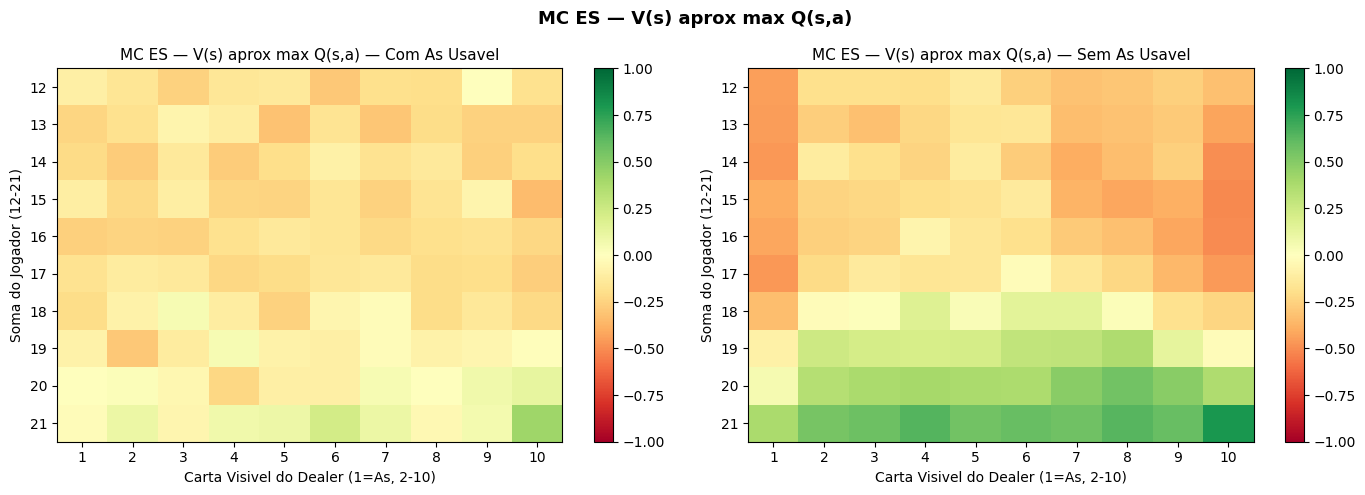

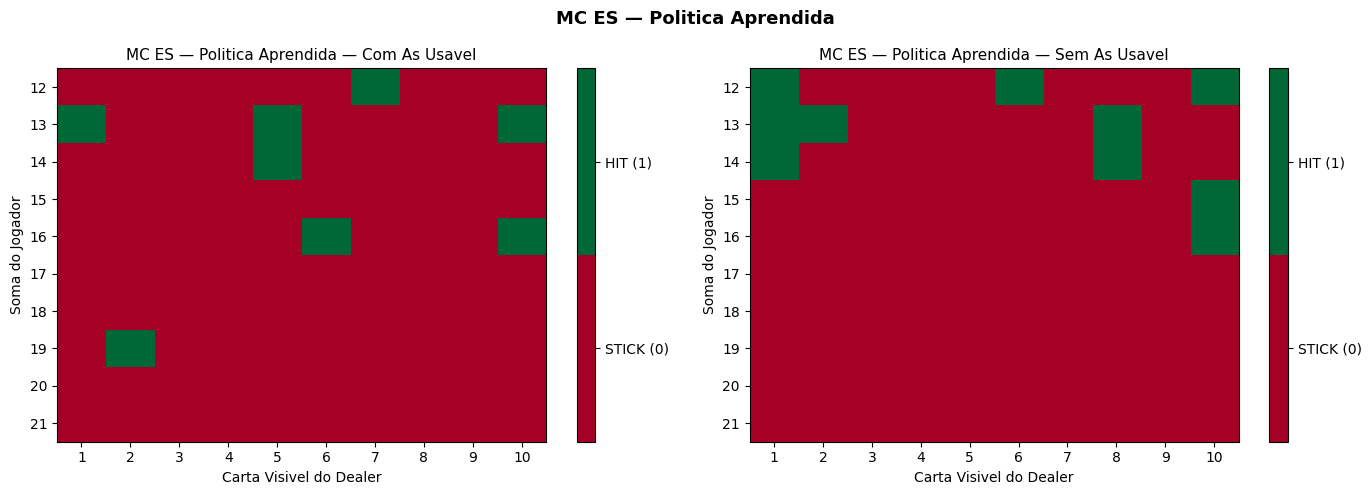


=== Avaliacao ===
  vitorias: 39.8%
  empates: 6.5%
  derrotas: 53.7%
CPU times: user 14.7 s, sys: 47.6 ms, total: 14.8 s
Wall time: 14.9 s


{'vitorias': 0.3983, 'empates': 0.0647, 'derrotas': 0.537}

In [ ]:
%%time
print('=== Monte Carlo ES Control ===')
env_es = BlackjackES()
Q_es, pi_es = mc_es_control(env_es, episodes=100000)

V_es = {s: max(Q_es.get((s, 0), 0.0), Q_es.get((s, 1), 0.0)) for s in pi_es}
plot_value_heatmap(V_es,   title='MC ES — V(s) aprox max Q(s,a)')
plot_policy_heatmap(pi_es, title='MC ES — Politica Aprendida')

print('\n=== Avaliacao ===')
avaliar_politica(env, lambda s: pi_es.get(s, 1), n_jogos=10000)

---

## 🔍 Análise Crítica — Por que o MC ES apresentou resultados ruins?

Antes de executar a versão corrigida, reflita sobre os problemas identificados
na implementação anterior. Esta análise é parte do aprendizado — entender
**por que um algoritmo falha** é tão importante quanto saber implementá-lo.

---

### 📋 Questão 1 — O bug dos Exploring Starts

Releia o trecho de `generate_episode_es` abaixo e identifique o problema:

```python
env_es.reset()   # (A) o que este reset faz?
next_state, reward, done = _step_env(env_es._env, A0)
trajectory.append((S0, reward, done, A0))   # (B) o que há de errado aqui?
```

**Perguntas:**
- Em qual estado o ambiente realmente está quando `A0` é executada?
- O estado registrado na trajetória (`S0`) corresponde ao estado real do ambiente?
- Como isso viola a premissa dos Exploring Starts definida pelo Sutton?

> 💡 *Dica: releia a definição de Exploring Starts na Seção 5.3 do Sutton (p. 99).
> O que o algoritmo garante sobre o par $(S_0, A_0)$?*

---

### 📋 Questão 2 — O espaço de estados amostrado

Observe o atributo `STATES` da versão original:

```python
STATES = [(ps, dc, ace)
          for ps in range(4, 22)   # ← soma do jogador começa em 4
          ...]
```

**Perguntas:**
- No Blackjack, o jogo começa com pelo menos duas cartas. Qual é a soma
  mínima relevante para a tomada de decisão?
- O que acontece com os pares $(s, a)$ amostrados para estados com soma
  muito baixa (ex: 4, 5, 6)? Eles são úteis para aprender a política?
- Como incluir estados inválidos no espaço amostral prejudica a cobertura
  dos estados que realmente importam?

---

### 📋 Questão 3 — Episódios insuficientes

O algoritmo foi treinado com `episodes=100000` sobre um espaço de:

$$|\mathcal{S}| \times |\mathcal{A}| = 360 \text{ estados} \times 2 \text{ ações} = 720 \text{ pares } (s, a)$$

**Perguntas:**
- Em média, quantas vezes cada par $(s, a)$ foi o ponto de partida de um
  episódio com 100.000 episódios?
- Por que uma estimativa de $Q(s, a)$ baseada em poucas amostras gera uma
  política greedy instável?
- Qual seria um número mais razoável de episódios para este problema?

---

### 📋 Questão 4 — Limitação fundamental do ES

O Gymnasium **não permite** definir o estado interno do ambiente diretamente.
Isso significa que, mesmo com a correção implementada em `reset_to()`, o
ES no Blackjack é sempre uma **aproximação**.

**Perguntas:**
- Que tipo de ambiente permitiria implementar os Exploring Starts de forma
  exata? Dê um exemplo.
- Por que o Algoritmo 3 (On-Policy MC com ε-greedy) é mais adequado para
  ambientes reais onde não controlamos o estado inicial?
- Qual é o custo que pagamos ao usar ε-greedy em vez de ES? O que perdemos
  em termos de qualidade da política final?

---

> ✅ Após refletir sobre as questões acima, execute as células corrigidas
> e compare os resultados com as versões anteriores. Verifique se as melhorias
> implementadas resolvem os problemas que você identificou.
```

In [ ]:
class BlackjackES:
    """
    Wrapper corrigido: usa replay de ações para aproximar o estado S0,
    já que o Gymnasium não permite setar o estado interno diretamente.
    """
    STATES  = [(ps, dc, ace)
               for ps  in range(12, 22)   # ← corrigido: estados relevantes só a partir de 12
               for dc  in range(1, 11)
               for ace in [True, False]]
    ACTIONS = [0, 1]

    def __init__(self):
        try:
            import gymnasium as gym
            self._env = gym.make('Blackjack-v1')
        except Exception:
            import gym
            self._env = gym.make('Blackjack-v0')

    def random_start(self) -> Tuple[State, int]:
        """Sorteia (S0, A0) do espaço de estados relevantes."""
        S0 = self.STATES[np.random.randint(len(self.STATES))]
        A0 = np.random.choice(self.ACTIONS)
        return S0, A0

    def reset_to(self, target_state: State) -> State:
        """
        Tenta aproximar o estado S0 fazendo resets até obter
        um estado compatível com target_state.
        Limita tentativas para não travar o loop.
        """
        soma_alvo, dealer_alvo, ace_alvo = target_state
        for _ in range(200):                    # máximo de tentativas
            state = _reset_env(self._env)
            soma, dealer, ace = state
            if dealer == dealer_alvo and ace == ace_alvo:
                return state                    # dealer e ás batem — aceita
        return _reset_env(self._env)            # fallback: estado qualquer


def generate_episode_es(env_es: BlackjackES, policy: dict,
                         S0: State, A0: int) -> Tuple[List, int]:
    """
    Episódio com Exploring Start corrigido:
    - Busca um estado real compatível com S0 via reset_to()
    - Executa A0 como primeira ação
    - Continua seguindo pi
    """
    real_state = env_es.reset_to(S0)           # ← estado real do ambiente
    trajectory = []

    # Primeiro passo forçado a partir do estado REAL
    next_state, reward, done = _step_env(env_es._env, A0)
    trajectory.append((real_state, reward, done, A0))   # ← usa real_state, não S0
    state = next_state

    while not done:
        action = policy.get(state, np.random.randint(2))
        next_state, reward, done = _step_env(env_es._env, action)
        trajectory.append((state, reward, done, action))
        state = next_state

    return trajectory, len(trajectory) - 1

In [ ]:
def mc_es_control(
    env_es:   BlackjackES,
    episodes: int   = 500000,    # ← aumentado de 100k para 500k
    gamma:    float = 1.0
) -> Tuple[QDict, dict]:

    Q             = defaultdict(float)
    Returns_sum   = defaultdict(float)
    Returns_count = defaultdict(int)
    pi            = {}

    # Inicialização otimista: encoraja exploração inicial
    for s in env_es.STATES:
        for a in env_es.ACTIONS:
            Q[(s, a)] = 0.0          # neutro — pode usar 1.0 para otimismo

    for ep in range(1, episodes + 1):
        S0, A0        = env_es.random_start()
        trajectory, T = generate_episode_es(env_es, pi, S0, A0)
        G       = 0.0
        visited = set()

        for t in reversed(range(T + 1)):
            state, reward, done, action = trajectory[t]
            G    = gamma * G + reward
            pair = (state, action)

            if pair not in visited:
                visited.add(pair)
                Returns_sum[pair]   += G
                Returns_count[pair] += 1
                Q[pair] = Returns_sum[pair] / Returns_count[pair]

                q0 = Q.get((state, 0), 0.0)
                q1 = Q.get((state, 1), 0.0)
                pi[state] = 0 if q0 >= q1 else 1

        if ep % 100000 == 0:
            print(f'  ep {ep:>6,}/{episodes:,}')

    return dict(Q), pi

=== Monte Carlo ES Control (versão demonstração — 50k episódios) ===
⚠️  Resultado parcial para fins de comparação estrutural.
    Comparação completa: ver Lição de Casa.



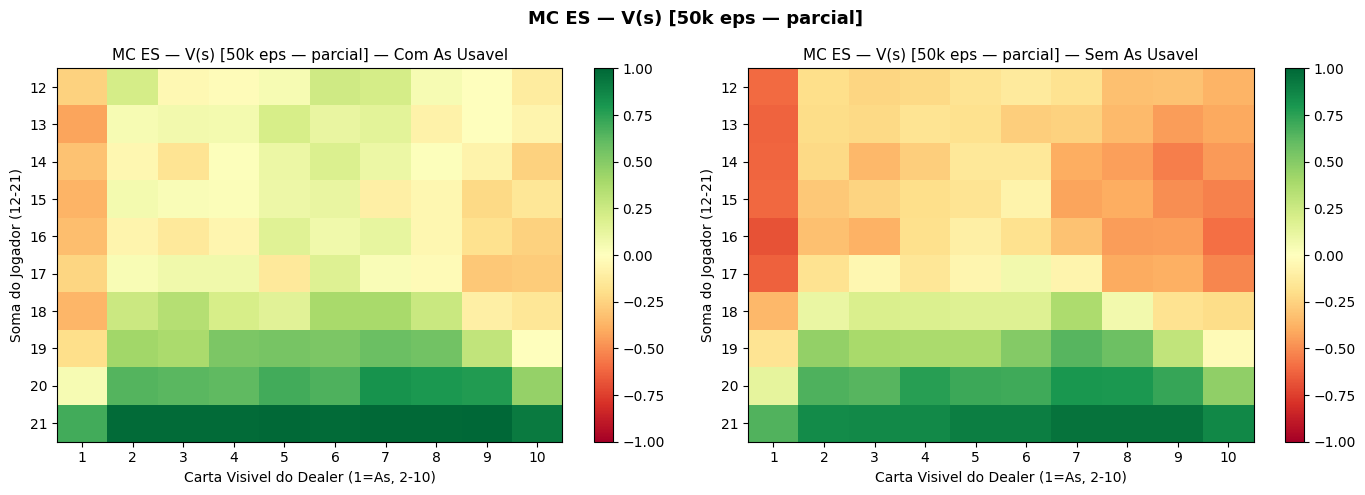

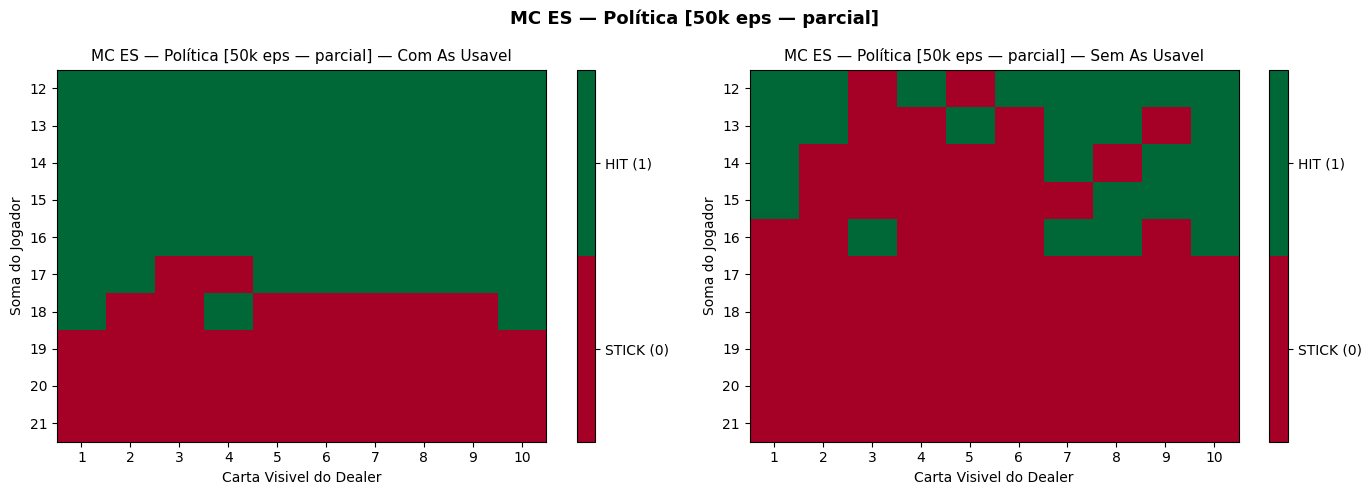


=== Avaliação ===
  vitorias: 42.6%
  empates: 9.8%
  derrotas: 47.6%
CPU times: user 2min 25s, sys: 112 ms, total: 2min 25s
Wall time: 2min 27s


{'vitorias': 0.4263, 'empates': 0.0976, 'derrotas': 0.4761}

In [ ]:
%%time
print('=== Monte Carlo ES Control (versão demonstração — 50k episódios) ===')
print('⚠️  Resultado parcial para fins de comparação estrutural.')
print('    Comparação completa: ver Lição de Casa.\n')

env_es  = BlackjackES()
Q_es, pi_es = mc_es_control(env_es, episodes=50000)

V_es = {s: max(Q_es.get((s, 0), 0.0), Q_es.get((s, 1), 0.0)) for s in pi_es}
plot_value_heatmap(V_es,   title='MC ES — V(s) [50k eps — parcial]')
plot_policy_heatmap(pi_es, title='MC ES — Política [50k eps — parcial]')

print('\n=== Avaliação ===')
avaliar_politica(env, lambda s: pi_es.get(s, 1), n_jogos=10000)

# Execute a célula a seguir em casa ( o tempo de execução é alto)

In [ ]:
# =====================================================
# 🏠 LIÇÃO DE CASA — Comparação MC ES vs On-Policy MC
# =====================================================
#
# Execute esta célula fora do horário de aula.
# Tempo estimado: 5–10 minutos dependendo da máquina.
#
# Objetivo: comparar o MC ES com episódios suficientes
# contra o On-Policy MC já treinado em aula (pi_op).

N_EPISODIOS = 500000   # ajuste conforme sua máquina

print(f'Treinando MC ES com {N_EPISODIOS:,} episódios...')
env_es_lc       = BlackjackES()
Q_es_lc, pi_es_lc = mc_es_control(env_es_lc, episodes=N_EPISODIOS)

# --- Visualizações ---
V_es_lc = {s: max(Q_es_lc.get((s, 0), 0.0), Q_es_lc.get((s, 1), 0.0))
           for s in pi_es_lc}
plot_value_heatmap(V_es_lc,   title=f'MC ES — V(s) [{N_EPISODIOS:,} eps]')
plot_policy_heatmap(pi_es_lc, title=f'MC ES — Política [{N_EPISODIOS:,} eps]')

# --- Comparação quantitativa ---
print('\n' + '='*55)
print(' COMPARAÇÃO FINAL — MC ES (500k) vs On-Policy MC (100k)')
print('='*55)

configs = [
    ('MC ES (500k eps)',      lambda s: pi_es_lc.get(s, 1)),
    ('On-Policy MC (100k eps)', lambda s: pi_op.get(s, 1)),   # treinado em aula
]
resultados_lc = {}
for nome, pol in configs:
    print(f'\n[{nome}]')
    resultados_lc[nome] = avaliar_politica(env, pol, n_jogos=10000)

# --- Questões para reflexão ---
print("""
📋 Responda no seu caderno:

1. Com 500k episódios, o MC ES superou o On-Policy MC (100k)?
   O que isso sugere sobre a eficiência dos dois algoritmos?

2. Compare as políticas nos heatmaps: as regiões de HIT/STICK
   são semelhantes? Onde diferem mais?

3. Considerando o tempo de execução de cada algoritmo,
   qual você escolheria para um problema real? Por quê?

4. O que aconteceria com o On-Policy MC se também usássemos
   500k episódios? Implemente e verifique.
""")

Treinando MC ES com 500,000 episódios...
  ep 100,000/500,000
  ep 200,000/500,000


---
## 🟢 Algoritmo 3 — On-Policy First-Visit MC Control

**Objetivo:** aprender a política ótima **sem** Exploring Starts, usando política **ε-greedy**.

$$
\pi(a|s) = \begin{cases}
1 - \varepsilon + \tfrac{\varepsilon}{|A|} & \text{se } a = \arg\max_a Q(s,a) \\
\tfrac{\varepsilon}{|A|} & \text{caso contrário}
\end{cases}
$$

```
Inicializar Q(s,a) = 0, N(s,a) = 0, epsilon > 0
Para cada episodio:
    Gerar episodio seguindo politica epsilon-greedy derivada de Q
    G <- 0
    Para t = T-1 ate 0:
        G <- gamma*G + R_{t+1}
        Se (St,At) e primeira visita:
            N(St,At) += 1
            Q(St,At) += (G - Q(St,At)) / N(St,At)   <- media incremental
```
> 📖 Sutton & Barto, Seção 5.4 (p. 101)

---

### Da teoria para o código: resolvendo o problema de cobertura

O Algoritmo 2 garantia cobertura forçando o par inicial $(S_0, A_0)$ — o que
vimos ser impraticável em ambientes reais. O Algoritmo 3 resolve o problema
de forma mais elegante: em vez de controlar o estado inicial, **torna a própria
política responsável pela exploração**.

A política ε-greedy é chamada de **política suave** (*soft policy*) porque
atribui probabilidade estritamente positiva a **todas** as ações em todos os
estados — nunca descarta completamente uma ação. Isso garante que todo par
$(s, a)$ seja visitado infinitas vezes no limite, sem nenhum mecanismo externo.

O parâmetro $\varepsilon$ controla o equilíbrio entre dois objetivos
conflitantes:

| $\varepsilon$ alto | $\varepsilon$ baixo |
|---|---|
| Mais exploração | Mais exploitation |
| Cobre o espaço de estados rapidamente | Converge para política mais próxima da ótima |
| Política final mais aleatória | Convergência mais lenta |

---

### `epsilon_greedy` — Implementação da política suave

```python
if np.random.random() < epsilon:
    return np.random.randint(n_actions)      # exploração: ação aleatória uniforme
```

Com probabilidade $\varepsilon$, ignora completamente $Q$ e escolhe uma ação
ao acaso. Isso garante que ações subótimas ainda sejam tentadas ocasionalmente
— essencial para não ficar preso em uma política subótima por falta de dados.

```python
q_vals = [Q.get((state, a), 0.0) for a in range(n_actions)]
max_q  = max(q_vals)
best   = [a for a, q in enumerate(q_vals) if q == max_q]
return np.random.choice(best)               # desempate aleatório
```

Com probabilidade $1 - \varepsilon$, escolhe a melhor ação conhecida segundo
$Q$. O desempate aleatório entre ações igualmente boas é importante no início
do treinamento, quando muitos pares $(s, a)$ ainda têm $Q = 0$ e qualquer
critério determinístico de desempate introduziria um viés.
```

---

### Implementação — `on_policy_mc_control`

#### A política como closure sobre Q

```python
policy = lambda s: epsilon_greedy(Q, s, n_actions, epsilon)
```

Este é um detalhe de implementação elegante e importante: `policy` é uma
função anônima que **captura `Q` por referência**. Isso significa que à medida
que `Q` é atualizado dentro do loop de episódios, a política automaticamente
passa a usar os valores mais recentes — sem precisar repassar `Q` explicitamente
a cada episódio. A política melhora de forma contínua e silenciosa ao longo
do treinamento.

#### Registro do histórico de recompensas

```python
history.append(trajectory[-1][1])   # recompensa final do episódio
```

No Blackjack, a recompensa só ocorre no último passo do episódio (`+1`, `0`
ou `-1`). Armazenar essa sequência em `history` permite plotar a curva de
convergência ao final — observando se o agente está de fato melhorando ao
longo do tempo.

#### Média incremental — eficiência sem perda de exatidão

```python
N[pair] += 1
Q[pair] += (G - Q[pair]) / N[pair]
```

Esta fórmula substitui o `np.mean(Returns[state])` do Algoritmo 1 e é
matematicamente idêntica à média aritmética de todos os retornos observados,
mas sem armazenar a lista. A derivação é direta:

$$Q_n = \frac{1}{n}\sum_{i=1}^n G_i = Q_{n-1} + \frac{1}{n}\bigl[G_n - Q_{n-1}\bigr]$$

Onde $G_n - Q_{n-1}$ é o **erro de estimativa** — a diferença entre o novo
retorno observado e a estimativa atual. Esse padrão de atualização reaparecerá
no TD-Learning e no Q-Learning com outra forma de calcular o erro.

#### Derivação da política greedy final

```python
states    = {s for (s, a) in Q}
pi_greedy = {s: max(range(n_actions), key=lambda a: Q.get((s, a), 0.0))
             for s in states}
```

Ao final do treinamento, extrai a política **completamente greedy** (sem $\varepsilon$)
a partir de $Q$. É esta política — não a ε-greedy usada durante o treino — que
é avaliada e comparada com as demais. Isso é importante: durante o treino
usamos ε-greedy para garantir exploração, mas na hora de jogar de verdade
queremos sempre a melhor ação conhecida.
```

---
### Execução e interpretação dos resultados

#### Gráfico de convergência

```python
rolling = pd.Series(history_op).rolling(window).mean()
```

A média móvel de 500 episódios suaviza o ruído das recompensas individuais
(que são sempre `+1`, `0` ou `-1`) e revela a tendência de aprendizado.
Observe no gráfico:

- **Fase inicial:** recompensa média próxima de `-1` — o agente ainda não
  aprendeu e perde com frequência.
- **Fase de aprendizado:** curva ascendente à medida que $Q$ melhora.
- **Fase de convergência:** oscilação em torno de um valor estável, ligeiramente
  abaixo de zero — reflexo do $\varepsilon = 0.1$ que força 10% de ações
  aleatórias mesmo após a convergência.

> 💡 **Por que a curva nunca atinge o máximo teórico?** A política ε-greedy
> nunca é 100% greedy — sempre há $\varepsilon$ de chance de uma ação ruim.
> Isso é o custo da exploração contínua: a política aprendida é a melhor
> política *suave*, não a melhor política *determinística*. Essa limitação
> é justamente o que motiva os métodos **off-policy** (Cap. 5.6–5.7 do Sutton),
> onde é possível aprender a política ótima determinística enquanto se
> comporta de forma exploratória.
```

In [ ]:
def epsilon_greedy(Q: QDict, state: State,
                   n_actions: int, epsilon: float) -> Action:
    """
    Seleciona acao epsilon-greedy.
    Com prob epsilon -> acao aleatoria (exploracao)
    Com prob 1-epsilon -> melhor acao em Q (explotacao)
    """
    if np.random.random() < epsilon:
        return np.random.randint(n_actions)
    q_vals = [Q.get((state, a), 0.0) for a in range(n_actions)]
    max_q  = max(q_vals)
    best   = [a for a, q in enumerate(q_vals) if q == max_q]
    return np.random.choice(best)   # desempate aleatorio

In [ ]:
def on_policy_mc_control(
    env,
    episodes:  int   = 100000,
    gamma:     float = 1.0,
    epsilon:   float = 0.1,
    n_actions: int   = 2
) -> Tuple[QDict, dict, List[float]]:
    """
    On-Policy First-Visit MC Control com epsilon-greedy.

    Retorna
    -------
    Q         : dict {(state, action): valor_Q}
    pi_greedy : politica greedy derivada de Q
    history   : recompensas por episodio (para grafico de convergencia)
    """
    Q       = defaultdict(float)
    N       = defaultdict(int)
    history = []

    policy  = lambda s: epsilon_greedy(Q, s, n_actions, epsilon)

    for ep in range(1, episodes + 1):
        trajectory, T = generate_episode(env, policy)
        history.append(trajectory[-1][1])  # recompensa final
        G       = 0.0
        visited = set()

        for t in reversed(range(T + 1)):
            state, reward, done, action = trajectory[t]
            G    = gamma * G + reward
            pair = (state, action)

            if pair not in visited:        # primeira visita
                visited.add(pair)
                N[pair] += 1
                # Media incremental: equivale a mean(Returns) sem guardar lista
                Q[pair] += (G - Q[pair]) / N[pair]

        if ep % 25000 == 0:
            media = np.mean(history[-2000:])
            print(f'  ep {ep:>6,}/{episodes:,} | media 2k: {media:+.3f}')

    states    = {s for (s, a) in Q}
    pi_greedy = {s: max(range(n_actions), key=lambda a: Q.get((s, a), 0.0))
                 for s in states}
    return dict(Q), pi_greedy, history

In [ ]:
%%time
print('=== On-Policy First-Visit MC Control (epsilon=0.1) ===')
Q_op, pi_op, history_op = on_policy_mc_control(
    env, episodes=100000, gamma=1.0, epsilon=0.1
)

V_op = {s: max(Q_op.get((s, 0), 0.0), Q_op.get((s, 1), 0.0)) for s in pi_op}
plot_value_heatmap(V_op,   title='On-Policy MC — V(s) aprox max Q(s,a)')
plot_policy_heatmap(pi_op, title='On-Policy MC — Politica Aprendida (eps=0.1)')

# Convergencia
window  = 500
rolling = pd.Series(history_op).rolling(window).mean()
plt.figure(figsize=(12, 3))
plt.plot(rolling, color='steelblue', linewidth=1.5)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title(f'Convergencia — On-Policy MC (media movel {window} eps)')
plt.xlabel('Episodio'); plt.ylabel('Recompensa Media')
plt.tight_layout(); plt.show()

print('\n=== Avaliacao ===')
avaliar_politica(env, lambda s: pi_op.get(s, 1), n_jogos=10000)

---
## 📊 4. Comparação dos Três Algoritmos

In [ ]:
print('=' * 60)
print(' COMPARACAO — Taxa de vitorias por algoritmo (10k jogos)')
print('=' * 60)

configs = [
    ('Politica Simples (>=20)', policy_simples),
    ('MC ES Control',           lambda s: pi_es.get(s, 1)),
    ('On-Policy MC (eps=0.1)',  lambda s: pi_op.get(s, 1)),
]
resultados = {}
for nome, pol in configs:
    print(f'\n[{nome}]')
    resultados[nome] = avaliar_politica(env, pol, n_jogos=10000)

fig, ax = plt.subplots(figsize=(10, 4))
nomes   = list(resultados.keys())
x, w    = np.arange(len(nomes)), 0.25
ax.bar(x - w, [resultados[n]['vitorias'] for n in nomes], w, label='Vitorias', color='green',  alpha=0.8)
ax.bar(x,     [resultados[n]['empates']  for n in nomes], w, label='Empates',  color='gold',   alpha=0.8)
ax.bar(x + w, [resultados[n]['derrotas'] for n in nomes], w, label='Derrotas', color='crimson', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(nomes, fontsize=9)
ax.set_ylabel('Proporcao'); ax.set_ylim(0, 0.6)
ax.legend(); ax.set_title('Comparacao de Politicas — Blackjack (10k jogos)')
plt.tight_layout(); plt.show()

---
## 🏆 5. Seção de Desafios

> Complete as células onde indicado com `# TODO`.

### 🟢 D1 — Compare os heatmaps das duas políticas de Predição
Execute a predição com `policy_avancada` e compare com `V_simples`.  
**Pergunta 1:** em quais estados a política avançada tem valor maior?
**Pergunta 2:** Gere uma nova politica e avalie os resultados

In [ ]:
V_avancada = first_visit_mc_prediction(
    env,
    policy=None,    # TODO: substitua None pela politica correta
    episodes=20000
)
# TODO: descomente e complete:
# plot_value_heatmap(V_avancada, title='...')

### 🟡 D2 (Médio) — Impacto do ε no On-Policy MC
Treine com `ε = 0.3` e compare a convergência com `ε = 0.1`.  
**Pergunta:** por que ε maior resulta em pior desempenho final?

In [ ]:
Q_ep3, pi_ep3, history_ep3 = on_policy_mc_control(
    env, episodes=100000, gamma=1.0,
    epsilon=0.0   # TODO: mude para 0.3
)
# TODO: plote as duas curvas no mesmo grafico
# r1 = pd.Series(history_op).rolling(500).mean()
# r2 = pd.Series(history_ep3).rolling(500).mean()
# plt.plot(r1, label='eps=0.1'); plt.plot(r2, label='eps=0.3')
# plt.legend(); plt.show()

### 🔴 D3 (Difícil) — Every-Visit MC Prediction
Modifique a função para atualizar $V(s)$ em **toda** visita (não só na primeira).  
**Pergunta:** os valores convergem para o mesmo resultado? O que a teoria diz?

In [ ]:
def every_visit_mc_prediction(
    env, policy: Policy,
    episodes: int = 20000,
    gamma:  float = 1.0
) -> dict:
    """
    Every-Visit MC Prediction.
    TODO: implemente removendo a condicao de primeira visita.
    """
    Returns = defaultdict(list)
    V = {}

    for ep in range(1, episodes + 1):
        trajectory, T = generate_episode(env, policy)
        G = 0.0

        for t in reversed(range(T + 1)):
            state, reward, done, action = trajectory[t]
            G = gamma * G + reward
            # TODO: atualize V(s) para TODA visita (sem checar visited)
            pass

    return V

# TODO: execute e compare os heatmaps:
# V_every = every_visit_mc_prediction(env, policy_simples, episodes=20000)
# plot_value_heatmap(V_every, title='Every-Visit MC')